# Multilayer Perceptron

            ## 1. Learning objectives

            - Use logits, softmax, and cross-entropy correctly
- Train a two-layer classifier
- Read training and validation curves

            ## 2. Prerequisites

            NumPy arrays, matrix multiplication, basic derivatives, and the supervised-learning workflow.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(1)
device = torch.device("cpu")
print("PyTorch:", torch.__version__, "| device:", device)

Python lesson ready; reproducible seed = 42
PyTorch: 2.14.0+cpu | device: cpu


## 3. Problem definition

            Classify images represented as fixed-length feature vectors with nonlinear hidden features.

            ## 4. Real-world use cases

            - Image recognition
- Sequence modeling
- Learned feature representations

            ## 5. Core intuition in simple language

            Each hidden unit detects a weighted pattern; the output logits score the ten possible digits.

## 6. Mathematical foundation

            $$p_k=\frac{e^{z_k}}{\sum_{j=1}^{K}e^{z_j}},\qquad L=-\log p_y.$$

            **Every symbol:**

            - $z_k$ is class k's logit.
- $K$ is class count.
- $p_k$ is class probability.
- $y$ is the correct class.
- $L$ is cross-entropy loss.

            **Why the equation is needed:** Softmax converts relative scores into probabilities and cross-entropy rewards probability on the correct class.

            **Small numerical example:** For logits [0,0], probabilities are [.5,.5]; if class 0 is correct, loss is -log(.5)=.693.

            **Connection to Python:** CrossEntropyLoss accepts raw logits and integer labels, combining log-softmax and negative log likelihood.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Create tensors with explicit batch and feature dimensions
2. Run a forward pass
3. Compute a loss against targets
4. Backpropagate gradients
5. Update parameters with an optimizer
6. Evaluate on untouched validation data

## 9. Implementation from scratch

NumPy exposes the forward calculation and, where appropriate, the gradients.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def softmax(values):
    shifted = values - values.max(axis=1, keepdims=True)
    exponentials = np.exp(shifted)
    return exponentials / exponentials.sum(axis=1, keepdims=True)

example_logits = np.array([[2.0, 1.0, 0.0]])
print("Softmax:", softmax(example_logits).round(3), "sum:", softmax(example_logits).sum())

Softmax: [[0.665 0.245 0.09 ]] sum: 0.9999999999999999


## 10. Implementation using a standard library

PyTorch tensors, modules, autograd, losses, and optimizers provide the standard implementation.

## 11. Dataset loading and exploration

Every lesson uses a generated sequence or a small dataset bundled with scikit-learn; no download is required.

## 12. Data preprocessing

Splits occur before fitted transformations. Inputs are converted to float32 tensors and class labels to int64.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Model diagnostics: {'input_shape': (1347, 64), 'intermediate_shape': (1347, 64), 'output_shape': (1347, 10), 'trainable_parameters': 4810, 'final_training_loss': 0.362, 'final_validation_loss': 0.3561, 'validation_accuracy': 0.882}


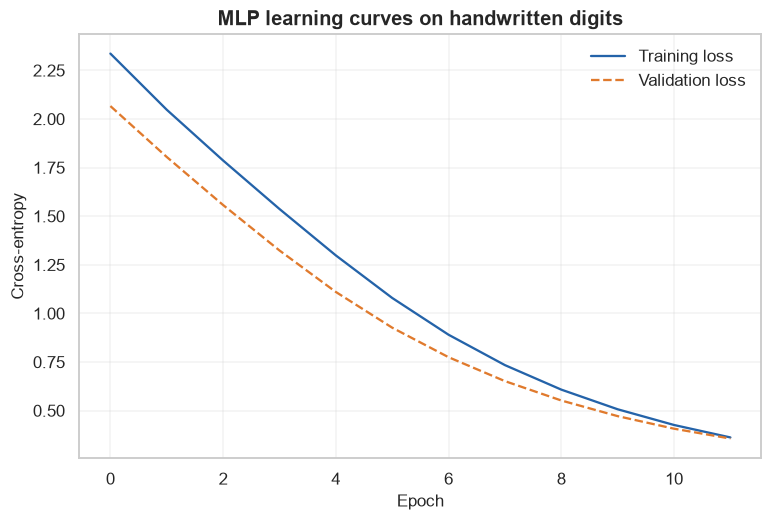

In [3]:
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X_train, X_validation, y_train, y_validation = train_test_split(
    digits.data, digits.target, test_size=.25, stratify=digits.target, random_state=RANDOM_SEED
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_validation = scaler.transform(X_validation)
train_X = torch.tensor(X_train, dtype=torch.float32)
train_y = torch.tensor(y_train, dtype=torch.long)
validation_X = torch.tensor(X_validation, dtype=torch.float32)
model = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 10))
optimizer = torch.optim.Adam(model.parameters(), lr=.01)
loss_fn = nn.CrossEntropyLoss()
train_losses = []; validation_losses = []
for epoch in range(12):
    model.train(); optimizer.zero_grad()
    logits = model(train_X); loss = loss_fn(logits, train_y); loss.backward(); optimizer.step()
    model.eval()
    with torch.no_grad():
        val_logits = model(validation_X)
        val_loss = loss_fn(val_logits, torch.tensor(y_validation, dtype=torch.long))
    train_losses.append(loss.item()); validation_losses.append(val_loss.item())
prediction = val_logits.argmax(dim=1).numpy()
validation_accuracy = accuracy_score(y_validation, prediction)
print("Model diagnostics:", {
    "input_shape": tuple(train_X.shape),
    "intermediate_shape": (len(train_X), 64),
    "output_shape": tuple(logits.shape),
    "trainable_parameters": sum(p.numel() for p in model.parameters()),
    "final_training_loss": round(train_losses[-1], 4),
    "final_validation_loss": round(validation_losses[-1], 4),
    "validation_accuracy": round(validation_accuracy, 3),
})
figure, axis = plt.subplots()
axis.plot(train_losses, label="Training loss", color=COURSE_COLORS["blue"])
axis.plot(validation_losses, label="Validation loss", color=COURSE_COLORS["orange"], linestyle="--")
axis.set(title="MLP learning curves on handwritten digits", xlabel="Epoch", ylabel="Cross-entropy")
axis.legend()
plt.show()

**How to interpret the result:** Falling validation loss alongside training loss indicates learning that generalizes to the held-out split.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Wider layers add representational capacity and parameters; selection should use validation performance, not size alone.

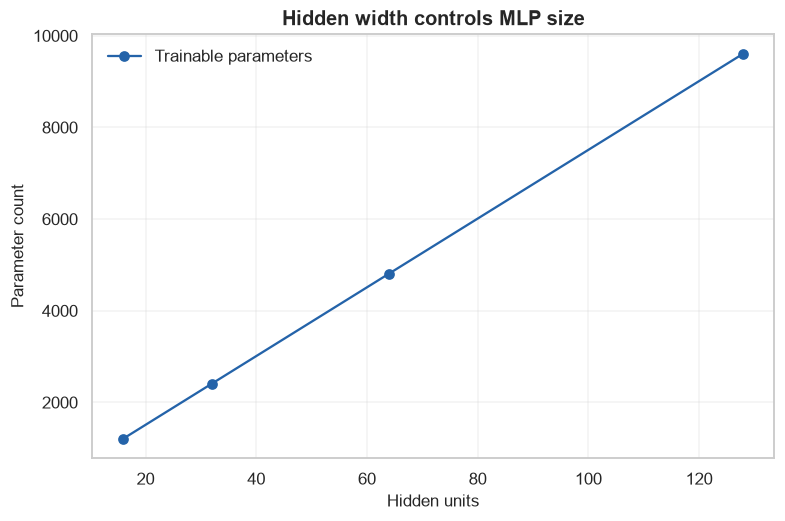

In [4]:
widths = [16, 32, 64, 128]
counts = [64*w+w+w*10+10 for w in widths]
figure, axis = plt.subplots()
axis.plot(widths, counts, marker="o", color=COURSE_COLORS["blue"], label="Trainable parameters")
axis.set(title="Hidden width controls MLP size", xlabel="Hidden units", ylabel="Parameter count")
axis.legend()
plt.show()

## 18. Common mistakes

            - Forgetting batch and feature dimensions
- Applying softmax before CrossEntropyLoss
- Evaluating on the training set
- Leaving gradients accumulated between optimizer steps

            ## 19. Advantages and disadvantages

            **Advantages**

            - Learns features jointly with predictions
- Flexible building blocks for structured data

            **Disadvantages**

            - Needs careful optimization and validation
- Can be computationally expensive and difficult to interpret

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the data and task benefit from learned nonlinear representations and validation supports the added complexity.

            **Do not use it when:** a small tabular dataset is handled well by a simpler, easier-to-audit model.

## 21. Exercises

1. **Conceptual:** Why do hidden layers need nonlinear activations?
2. **Mathematical/hand calculation:** Calculate ReLU([−2, 0, 3]).
3. **Coding/experimentation:** Double hidden width and compare parameter count and validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Without nonlinearities, multiple affine layers equal one affine layer.
2. The result is [0, 0, 3].
3. Change the layer width, count parameters, retrain with the same split, and compare training-versus-validation loss rather than training loss alone.

</details>

## 23. Summary and key takeaways

            - Tensor shapes are part of the model specification
- Forward propagation produces predictions and backpropagation produces gradients
- Training and validation curves reveal optimization and generalization

            ## 24. Further reading

            - [PyTorch tutorials](https://pytorch.org/tutorials/)
- [PyTorch neural-network modules](https://pytorch.org/docs/stable/nn.html)